<a href="https://colab.research.google.com/github/ChenHY1217/Projects-In-MLAI/blob/main/ProjectsinMLAIhw4_task2%263.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sequence Models

## Task 2 - Implementing a RNN

dataset link: https://www.kaggle.com/datasets/mnassrib/jena-climate

I decided to choose the Jena Climate Time series dataset on Weather prediction. Our goal is to predict future air temperature, T (degC), based on a history of recent meterological observations. We need a sequencial model for this problem because meterological data is fundamentally temporal. The order of the data points affects the outcome. Standard FNNs treat each feature separately without keeping into account the order / sequence of the data. In contrast, RNNs maintain a hidden state as it processes data step by step. This captures the time dependencies and trends.

### Import data, EDA, and Feature Engineering

Import dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import kagglehub

# Download dataset
path = kagglehub.dataset_download("mnassrib/jena-climate")
df = pd.read_csv(path + "/jena_climate_2009_2016.csv")

# check for missing values
print(df.isnull().sum())

# Downsample, taking every 6th record to convert 10-minute data to hourly data
df = df.iloc[5::6].reset_index(drop=True)
print(df.head())

print(df.shape)

100%|██████████| 13.2M/13.2M [00:00<00:00, 196MB/s]

Extracting files...


Date Time          0
p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 01:00:00    996.50     -8.05    265.38        -8.78    94.4   
1  01.01.2009 02:00:00    996.62     -8.88    264.54        -9.77    93.2   
2  01.01.2009 03:00:00    996.84     -8.81    264.59        -9.66    93.5   
3  01.01.2009 04:00:00    996.99     -9.05    264.34       -10.02    92.6   
4  01.01.2009 05:00:00    997.46     -9.63    263.72       -10.65    92.2   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.14          0.19       1.96             3.15   
1          3.12          2.90          0.21       1.81     

EDA and Feature Engineering

We group the data into 24 hour windows to predict the next 1 hour's temperature.

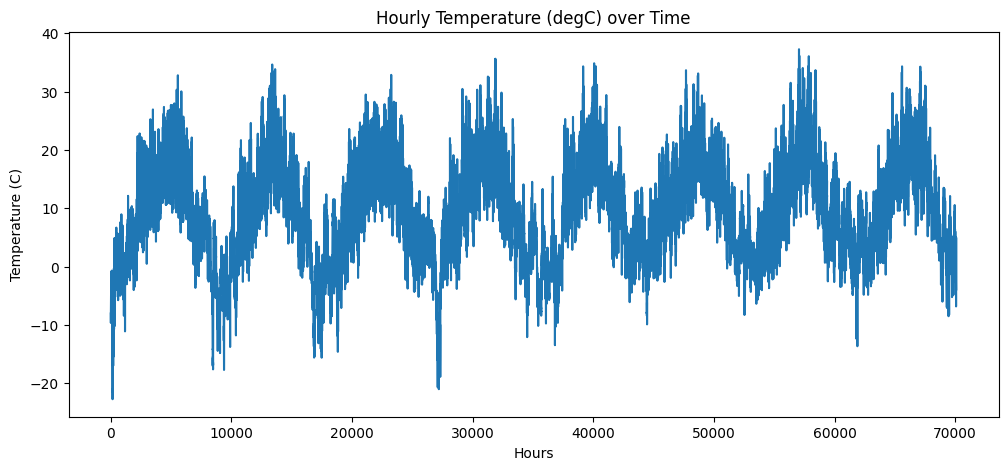

Features shape: (70067, 24, 12)
Target shape: (70067,)


In [ ]:
# drop redundant columns
features_to_drop = ['Date Time', 'Tpot (K)', 'Tdew (degC)']
df_features = df.drop(columns=features_to_drop)

# Let's plot the target variable T (degC)
plt.figure(figsize=(12, 5))
plt.plot(df['T (degC)'])
plt.title('Hourly Temperature (degC) over Time')
plt.xlabel('Hours')
plt.ylabel('Temperature (C)')
plt.show()

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

target_idx = df_features.columns.get_loc('T (degC)')

# Create sliding window sequences
def create_sequences(data, seq_length, target_index):
    X, y = [], []
    for i in range(len(data) - seq_length):
        # The past 'seq_length' hours of all features
        X.append(data[i : i + seq_length])
        # The temperature 1 hour after the sequence ends
        y.append(data[i + seq_length, target_index])
    return np.array(X), np.array(y)

# We will use the past 24 hours to predict the next 1 hour
sequence_length = 24
X, y = create_sequences(scaled_data, sequence_length, target_idx)

print(f"Features shape: {X.shape}") # Should be (Samples, 24, Num_Features)
print(f"Target shape: {y.shape}")   # Should be (Samples,)

Additional Data Visualization

Let's analyze the relationships between features and their distributions.

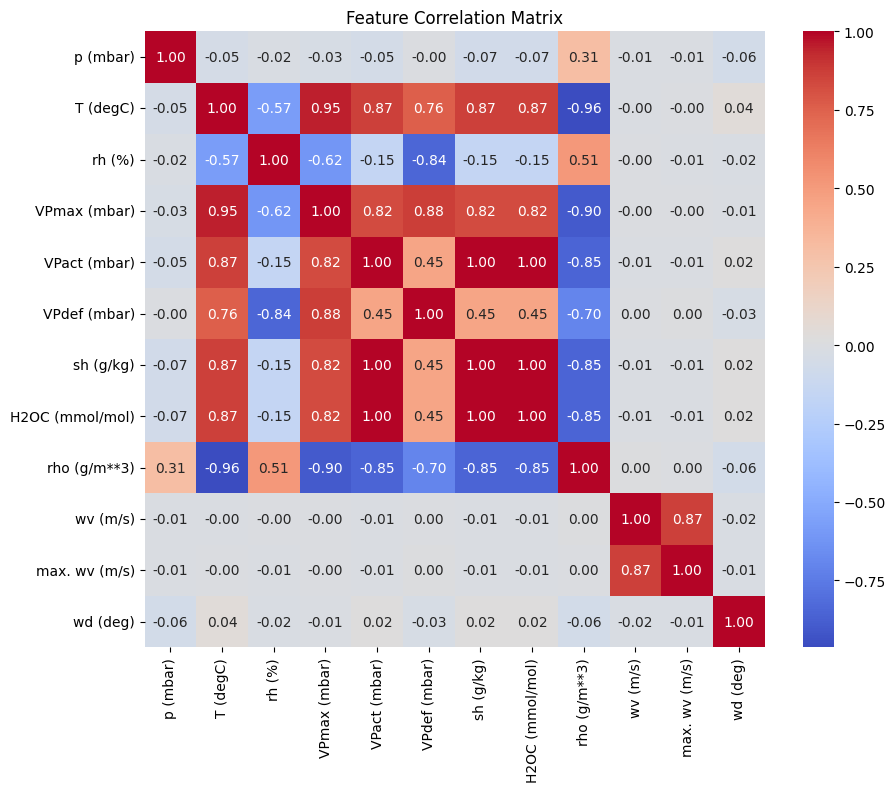

In [ ]:
import seaborn as sns

# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_features.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

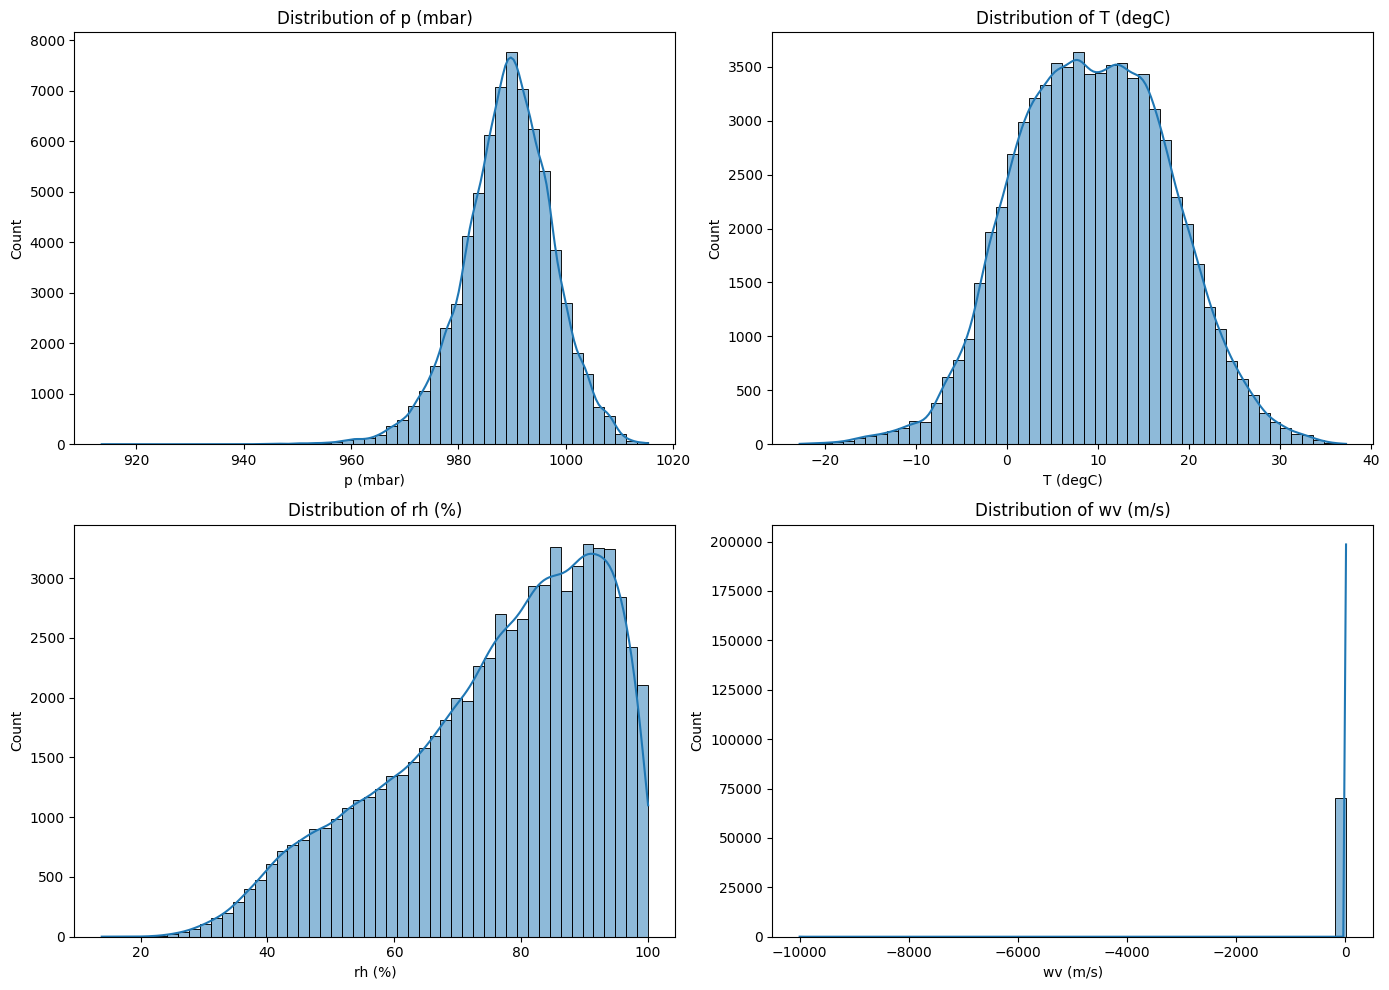

In [ ]:
# Plot distributions of key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features_to_plot = ['p (mbar)', 'T (degC)', 'rh (%)', 'wv (m/s)']

for i, feature in enumerate(features_to_plot):
    row, col = i // 2, i % 2
    sns.histplot(df_features[feature], bins=50, kde=True, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

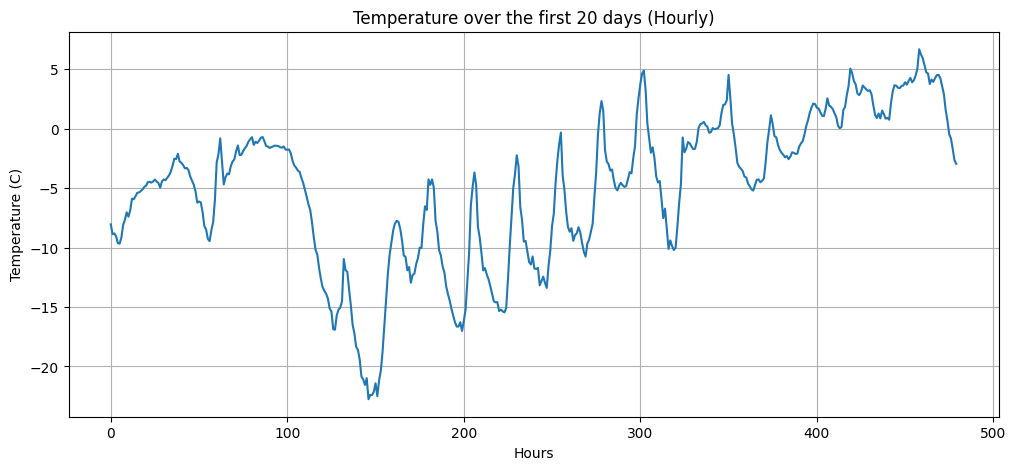

In [ ]:
# Zoom into the first 480 hours (20 days) to see the daily pattern
plt.figure(figsize=(12, 5))
plt.plot(df['T (degC)'][:480])
plt.title('Temperature over the first 20 days (Hourly)')
plt.xlabel('Hours')
plt.ylabel('Temperature (C)')
plt.grid(True)
plt.show()

Train Val Test Split

In [ ]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size : train_size+val_size], y[train_size : train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

# Convert Numpy arrays to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1) # Add dimension for output

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(-1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

# Create PyTorch DataLoaders
batch_size = 128

train_loader = DataLoader(torch.utils.data.TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(torch.utils.data.TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(torch.utils.data.TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

### Model Structure and Activations

The model follows a "Many-to-One" architecture. It takes a sequence of 24 time steps (hours), where each step contains the weather features. The RNN processes these steps sequentially, updating its hidden state. We then take the output of the final time step and pass it through a fully connected (Linear) layer to predict a single continuous value: the temperature for the next hour.

At each time step within the nn.RNN cell, the model uses the Hyperbolic Tangent (tanh) activation function. This is the default in PyTorch and helps regulate the hidden state values between -1 and 1, preventing them from exploding during the sequence processing.

The final layer is a standard Linear layer with no activation function (or an Identity activation) because this is a regression task.

The model will be evaluated using Mean Squared Error (MSE). MSE is standard for regression as it heavily penalizes larger prediction errors, which is highly desirable in weather forecasting (a 5-degree error is much worse than five 1-degree errors). This will also be the metric for measuring performance.

### Part 1 - Implementing and Running the RNN

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# move to gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

class WeatherRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(WeatherRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # batch_first=True because our data shape is (batch, seq_len, features)
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # Forward propagate the RNN
        # 'out' contains the output features from the last layer of the RNN for each time step
        out, _ = self.rnn(x, h0)

        # We care about the hidden state of the very last time step (out[:, -1, :])
        # Pass it through the linear head to get our prediction
        prediction = self.fc(out[:, -1, :])
        return prediction

# Determine input size dynamically from your dataset features
input_dim = X_train_t.shape[2]
hidden_dim = 64
output_dim = 1

# Instantiate the model and move it to the GPU
model = WeatherRNN(input_dim, hidden_dim, output_dim).to(device)

Training on: cuda


Training Loop

In [ ]:
def train_and_evaluate(model, model_name, num_epochs=20):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)

        train_losses.append(running_train_loss / len(train_loader.dataset))

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)
        val_losses.append(running_val_loss / len(val_loader.dataset))

    # Test Set Evaluation
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            test_loss += criterion(outputs, targets).item() * inputs.size(0)
    final_test_mse = test_loss / len(test_loader.dataset)

    print(f'--- {model_name} ---')
    print(f'Final Test Set Loss (MSE): {final_test_mse:.4f}\n')

    # Plotting
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss')
    plt.title(f'{model_name}: Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.show()

--- RNN Model ---
Final Test Set Loss (MSE): 0.0063



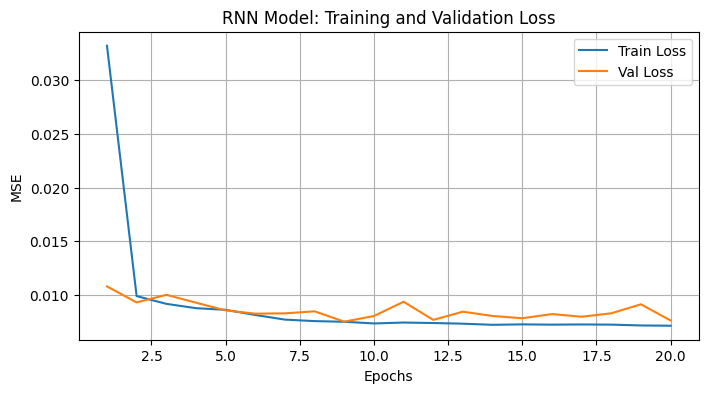

In [ ]:
train_and_evaluate(model, "RNN Model")

### Part 2 - LSTM and GRU

In [ ]:
# --- The LSTM Model ---
class WeatherLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(WeatherLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # LSTM requires both a hidden state (h0) and a cell state (c0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # out shape: (batch_size, seq_length, hidden_size)
        out, _ = self.lstm(x, (h0, c0))

        # Take the output of the last time step
        prediction = self.fc(out[:, -1, :])
        return prediction

# --- The GRU Model ---
class WeatherGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(WeatherGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        out, _ = self.gru(x, h0)
        prediction = self.fc(out[:, -1, :])
        return prediction

lstm_model = WeatherLSTM(input_dim, hidden_dim, output_dim).to(device)
gru_model = WeatherGRU(input_dim, hidden_dim, output_dim).to(device)

Rerun Training and Testing

--- LSTM Model ---
Final Test Set Loss (MSE): 0.0060



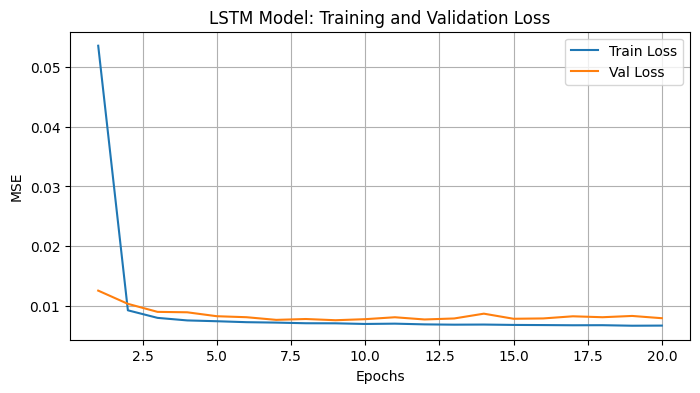

--- GRU Model ---
Final Test Set Loss (MSE): 0.0061



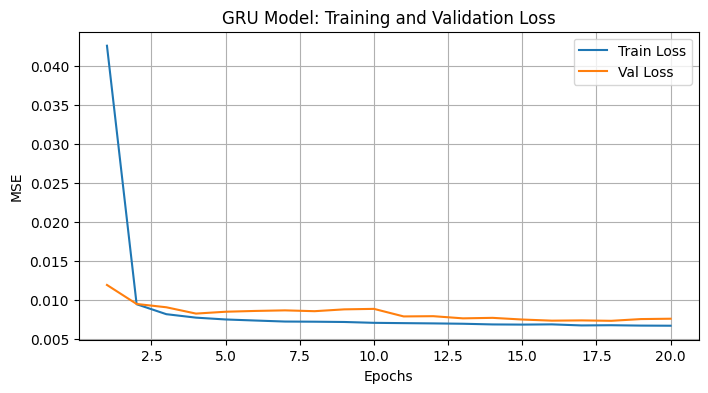

In [ ]:
# Run the training for both new models
train_and_evaluate(lstm_model, "LSTM Model")
train_and_evaluate(gru_model, "GRU Model")

Major Differences:

Both LSTM and GRU has less MSE compared to basic RNN and more significantly, both have a much smoother decreasing loss curve for validation. This means that LSTM and GRU will generally converge smoother and faster. Another difference is that RNN trains much faster than the other two with LSTM being the slowest due to the extra computations internally.

The reason these differences exist is because of the internal architecture and the vanishing gradient problem. The basic RNN suffers from this as when it backpropagates, the gradient shrinks exponentially, making it forget the contributions of the earlier steps in the sequence. This is solved through the introduction of cell states and other gates in LSTM and similar gates in GRU.

### Part 3 - Comparison with FNN

Technically, yes you can use a FNN for this problem. Right now, the RNN takes in a 2D window shape for the features over 24 hours. To make it work with FNN, we would need to flatten into 1D vectors. This creates massive 1D input rows with many features.

However, this is not ideal because now the weights at each timestep is independent of each other so the model does not understand the connections and will not reflect them in the results. It also does not have "memory". We also have a fixed input size whereas a RNN can process sequences of variable lengths.

## Task 3 - Word Embeddings

We will be using GloVe because it captures global semantic relationships the best.

This is better than Word2Vec because GloVe uses global word co-occurence matrices to capture global semantic relationships better than Word2Vec. In comparison to FastText which is naturally immune to OOV errors, GloVe forces us to explicitly define an OOV handling strategy, which is suited for this assignment. Finally, BERT creates contextualized embeddings where words have different vectors based on their context. Since we want to compute static similarity between isolated word pairs, GloVe is lighter and more appropriate in this case.

In this case, we will handle OOV instances by returning a zero vector to ensure math operations don't crash, effectively treating the unknown word as having zero semantic similarity to any known word.

Links:
* https://www.geeksforgeeks.org/nlp/glove-word-embedding-in-nlp/


In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.7 MB/s eta 0:00:00


In [3]:
import gensim.downloader as api
import numpy as np

print("Downloading/Loading GloVe model...")
glove_model = api.load("glove-wiki-gigaword-50")
print("Model loaded successfully!")

# Function to fetch embeddings and handle Out-of-Vocabulary (OOV) cases
def get_word_embedding(word, model):
    word = word.lower().strip()
    if word in model:
        return model[word]
    else:
        print(f"  [Warning] '{word}' is Out of Vocabulary (OOV).")
        return np.zeros(model.vector_size)

# Dynamic User Input
def interactive_embedding_fetch():
    print("\n--- Word Embedding Fetcher ---")
    word1 = input("Enter the first word: ")
    word2 = input("Enter the second word: ")

    emb1 = get_word_embedding(word1, glove_model)
    emb2 = get_word_embedding(word2, glove_model)

    print(f"\nEmbedding for '{word1}':\n{emb1[:5]}... (shape: {emb1.shape})")
    print(f"Embedding for '{word2}':\n{emb2[:5]}... (shape: {emb2.shape})")

    return word1, word2, emb1, emb2

# Run the interactive prompt
w1, w2, e1, e2 = interactive_embedding_fetch()

Downloading/Loading GloVe model...
[==================================================] 100.0% 66.0/66.0MB downloaded
Model loaded successfully!

--- Word Embedding Fetcher ---
Enter the first word: cosine
Enter the second word: sine

Embedding for 'cosine':
[ 1.2251 -2.0855 -1.021   1.1612  1.0346]... (shape: (50,))
Embedding for 'sine':
[ 0.65789 -1.1622  -0.945    0.40355  0.15238]... (shape: (50,))


### Cosine Similarity

Cosine Similarity is useful in the word embeddings space. If we only look at the magnitude of vectors which correlates to how frequently that word appears in training, we can miss out on semantic similarities. If we look at standard Euclidean distance, words that have similar meaning can be mathematically far apart if one of the words is more obscure. Therefore, we look at only the angle between the two vectors to measure their similarity.

In [4]:
import numpy as np

# Cosine Similarity function
def compute_cos_similarity(emb1, emb2):
    dot_product = np.dot(emb1, emb2)
    norm_emb1 = np.linalg.norm(emb1)
    norm_emb2 = np.linalg.norm(emb2)
    return dot_product / (norm_emb1 * norm_emb2)

# Batch Processing Function
def batch_cosine_similarity(word_pairs, model):
    """
    Takes a list of word tuples and computes similarity for all of them.
    Example input: [('cat', 'dog'), ('car', 'bicycle'), ('apple', 'truck')]
    """
    results = {}
    print("--- Batch Similarity Results ---")
    for w1, w2 in word_pairs:
        # Get embeddings using the function we defined in Part 1
        vec1 = get_word_embedding(w1, model)
        vec2 = get_word_embedding(w2, model)

        sim = compute_cos_similarity(vec1, vec2)
        results[f"{w1} vs {w2}"] = sim
        print(f"Similarity({w1}, {w2}): {sim:.4f}")

    return results

# Test the batch processing
pairs_to_test = [
    ("cat", "dog"),
    ("king", "queen"),
    ("cat", "car"),
    ("happy", "sad"),
    ("python", "java")
]

batch_results = batch_cosine_similarity(pairs_to_test, glove_model)

--- Batch Similarity Results ---
Similarity(cat, dog): 0.9218
Similarity(king, queen): 0.7839
Similarity(cat, car): 0.3638
Similarity(happy, sad): 0.6891
Similarity(python, java): 0.4767


In [6]:
user_inputs = []
print("\n--- User Input Processing (Batch) ---")
while True:
    print("Enter two words (or 'exit' to quit):")
    user_input1 = input("First word: ").lower().strip()
    if user_input1 == "exit":
        break
    user_input2 = input("Second word: ").lower().strip()
    if user_input2 == "exit":
        break
    user_inputs.append((user_input1, user_input2))

# Batch Processing
batch_results = batch_cosine_similarity(user_inputs, glove_model)


--- User Input Processing (Batch) ---
Enter two words (or 'exit' to quit):
First word: hi
Second word: hello
Enter two words (or 'exit' to quit):
First word: cat
Second word: dog
Enter two words (or 'exit' to quit):
First word: money
Second word: dollar
Enter two words (or 'exit' to quit):
First word: exit
--- Batch Similarity Results ---
Similarity(hi, hello): 0.3972
Similarity(cat, dog): 0.9218
Similarity(money, dollar): 0.5997


Visualization with PCA

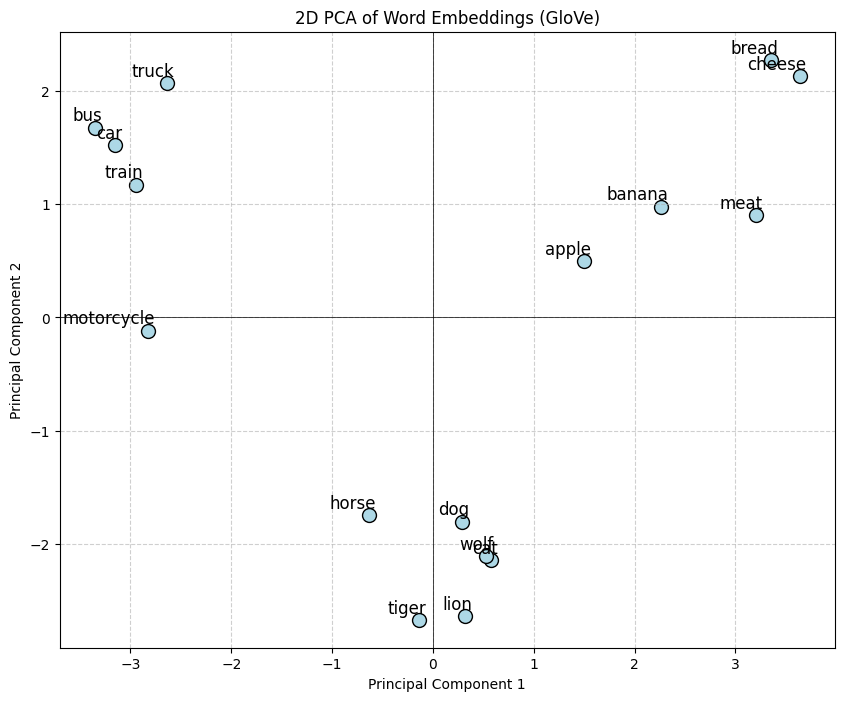

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_word_clusters(words, model):
    # Filter OOV words
    valid_words = [w for w in words if w in model]
    vectors = np.array([model[w] for w in valid_words])

    # Reduce the 50-dimensional vectors down to 2 dimensions using PCA
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)

    # Create the scatter plot
    plt.figure(figsize=(10, 8))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], edgecolors='k', c='lightblue', s=100)

    # Annotate the points with their corresponding words
    for i, word in enumerate(valid_words):
        plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
                     xytext=(5, 2), textcoords='offset points', ha='right', va='bottom', fontsize=12)

    plt.title('2D PCA of Word Embeddings (GloVe)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axhline(0, color='black',linewidth=0.5)
    plt.axvline(0, color='black',linewidth=0.5)
    plt.show()

# A curated list of words to show distinct clusters (Animals vs Vehicles vs Food)
clustering_words = [
    "dog", "cat", "wolf", "lion", "tiger", "horse",     # Animals
    "car", "truck", "bus", "train", "motorcycle",       # Vehicles
    "apple", "banana", "bread", "cheese", "meat"        # Food
]

plot_word_clusters(clustering_words, glove_model)

### Designing a Novel Dissimilarity Metric

We will be using Euclidean distance as the custom metric. Although Cosine similarity is great at capturing semantic direction, it completely ignores the magnitude of word vectors. By using Euclidean distnace, we can measure the distance between two points in space. This way if two words are related semantically but one is common and one is niche, this metric will penalize them, capturing a type of context novelty that Cosine Similarity misses.

/tmp/ipykernel_1044/198246141.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cosine_scores, y=valid_words, ax=ax1, palette='viridis')
/tmp/ipykernel_1044/198246141.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=euclidean_scores, y=valid_words, ax=ax2, palette='magma')


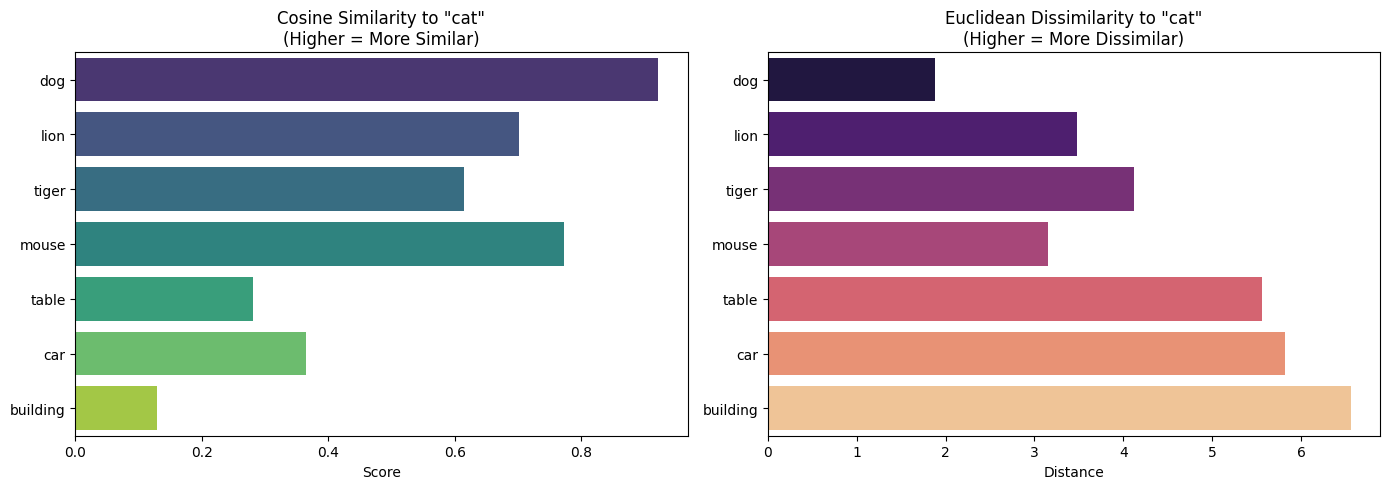


Generating Cosine Heatmap...


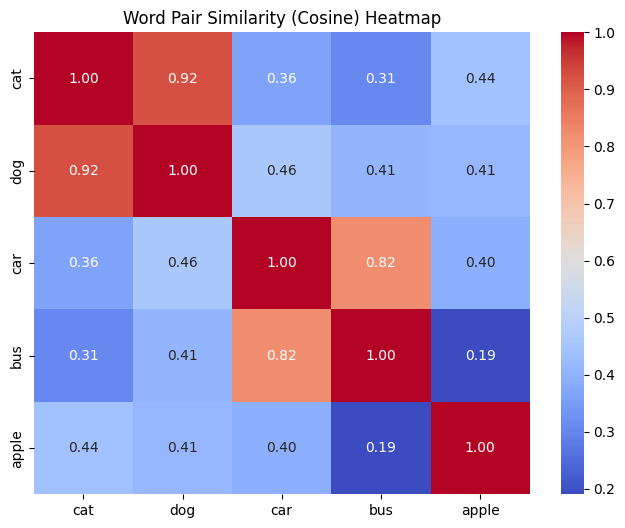


Generating Euclidean Heatmap...


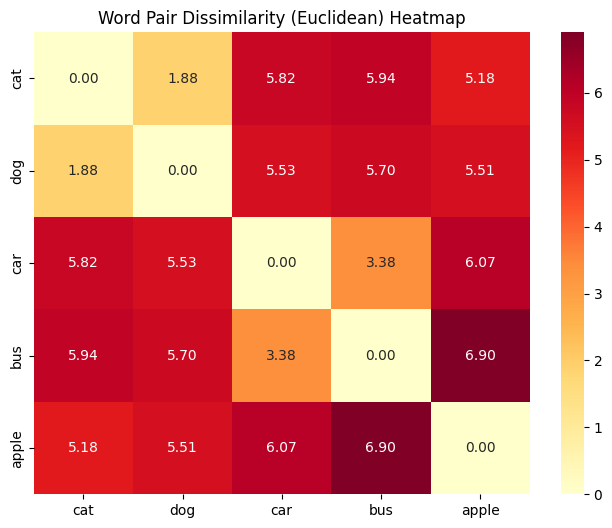

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import norm

# Toggleable metric function
def compute_distance(vec1, vec2, metric='cosine'):
    """Computes Cosine similarity or Euclidean Distance dissimilarity based on the chosen metric."""
    if norm(vec1) == 0 or norm(vec2) == 0:
        return 0.0 if metric == 'cosine' else float('inf')

    if metric == 'cosine':
        # Higher is more similar (1.0 is identical)
        return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))
    elif metric == 'euclidean':
        # Lower is more similar (0.0 is identical), this is a Dissimilarity score
        return norm(vec1 - vec2)
    else:
        raise ValueError("Metric must be 'cosine' or 'euclidean'")

# Word Ranking Visualization
def plot_word_ranking(target_word, comparison_words, model):
    """Plots how words rank against a target word using both metrics."""
    target_vec = get_word_embedding(target_word, model)

    cosine_scores = []
    euclidean_scores = []
    valid_words = [w for w in comparison_words if w in model]

    for word in valid_words:
        vec = get_word_embedding(word, model)
        cosine_scores.append(compute_distance(target_vec, vec, metric='cosine'))
        euclidean_scores.append(compute_distance(target_vec, vec, metric='euclidean'))

    # Set up the subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Cosine Similarity (Higher is better)
    sns.barplot(x=cosine_scores, y=valid_words, ax=ax1, palette='viridis')
    ax1.set_title(f'Cosine Similarity to "{target_word}"\n(Higher = More Similar)')
    ax1.set_xlabel('Score')

    # Plot Euclidean Distance (Lower is better)
    sns.barplot(x=euclidean_scores, y=valid_words, ax=ax2, palette='magma')
    ax2.set_title(f'Euclidean Dissimilarity to "{target_word}"\n(Higher = More Dissimilar)')
    ax2.set_xlabel('Distance')

    plt.tight_layout()
    plt.show()

# Test the ranking
target = "cat"
comparisons = ["dog", "lion", "tiger", "mouse", "table", "car", "building"]
plot_word_ranking(target, comparisons, glove_model)


# Heatmap Visualization
def plot_similarity_heatmap(words, model, metric='cosine'):
    """Generates a heatmap for a list of words using the chosen metric."""
    valid_words = [w for w in words if w in model]
    n = len(valid_words)
    matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            vec1 = get_word_embedding(valid_words[i], model)
            vec2 = get_word_embedding(valid_words[j], model)
            matrix[i, j] = compute_distance(vec1, vec2, metric=metric)

    plt.figure(figsize=(8, 6))
    # Adjust color map based on metric
    cmap = 'coolwarm' if metric == 'cosine' else 'YlOrRd'
    title_suffix = 'Similarity (Cosine)' if metric == 'cosine' else 'Dissimilarity (Euclidean)'

    sns.heatmap(matrix, xticklabels=valid_words, yticklabels=valid_words,
                annot=True, fmt=".2f", cmap=cmap)
    plt.title(f'Word Pair {title_suffix} Heatmap')
    plt.show()

# Test the heatmap with both metrics
heatmap_words = ["cat", "dog", "car", "bus", "apple"]
print("\nGenerating Cosine Heatmap...")
plot_similarity_heatmap(heatmap_words, glove_model, metric='cosine')

print("\nGenerating Euclidean Heatmap...")
plot_similarity_heatmap(heatmap_words, glove_model, metric='euclidean')